In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
%pip install numpy
%pip install pandas
%pip install pytest
%pip install requests
%pip install ipywidgets
%pip install jupyter_ui_poll

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

## Http fundermentals

**Using urllib to get geocoding into**

In [37]:
import json
import urllib.parse
import urllib.request

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10
location='dresden'

try:
    params = {"name": location, "count": 1, "language": 'en', "format": 'json'}
    url = f"{base_url}?{urllib.parse.urlencode(params)}"
    with urllib.request.urlopen(url, timeout=time_out) as resp:
        results = json.load(resp).get("results", [])
        results[0]['latitude'], results[0]['longitude']

        print("Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)\n" , f"Location:{location}\n", f"Latitude:{results[0]['latitude']}", f"Longitude:{results[0]['longitude']}")
except Exception as e:
    print(e)    



Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)
 Location:dresden
 Latitude:51.05089 Longitude:13.73832


**Using Requests to get geocoding info**

In [38]:
import json
import requests

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10
location='dresden'

try:
    params = {"name": location, "count": 1, "language": 'en', "format": 'json'}
    resp = requests.get(base_url, params=params, timeout=time_out)
    resp.raise_for_status()
    results = resp.json().get("results", [])
    results[0]['latitude'], results[0]['longitude']

    print("Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)\n" , f"Location:{location}\n", f"Latitude:{results[0]['latitude']}", f"Longitude:{results[0]['longitude']}")
except Exception as e:
    print(e)   

Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)
 Location:dresden
 Latitude:51.05089 Longitude:13.73832


## Comparing urllib and requests

| | urllib | requests |
|---|---|---|
| How much code | More. I had to build the URL myself, open it, read the response and turn it into JSON. | Less. I pass the parameters in a dictionary and call `.json()` to get the data. |
| Handling errors | It raises different errors for different problems (`HTTPError` for a bad response, `URLError` for a network problem), so I have to catch each one. | `raise_for_status()` checks for a bad response, and `requests.RequestException` catches every kind of error in one go. |
| Sending headers | I have to create a `Request` object first to add headers. | I just pass `headers={...}` to `requests.get()`. |
| Encoding | I encode the URL with `urlencode` and decode the response myself. | It encodes the URL and decodes the response for me. |
| Installing | Nothing to install. It comes with Python. | I need to install it with `pip install requests`. |

urllib works without installing anything, but I had to write more code and handle more of the details myself. requests did the same job in fewer lines and was easier to read, so I would use it unless I couldn't install extra packages.

## Status code, the Content-Type header, and the response time 

In [39]:
import requests

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10
location='dresden'

params = {"name":location, "count": 1, "language": "en", "format": "json"}
resp = requests.get(base_url, params=params, timeout=time_out)

print("Status code:  ", resp.status_code)
print("Content-Type: ", resp.headers["Content-Type"])
print(f"Response time: {resp.elapsed.total_seconds() * 1000:.0f} ms")

Status code:   200
Content-Type:  application/json; charset=utf-8
Response time: 907 ms


## Forecast retreival and display

In [ ]:
import requests


def geocode(location):
    base_url = "https://geocoding-api.open-meteo.com/v1/search"
    time_out = 10
    params = {"name": location, "count": 10, "language": 'en', "format": 'json'}
    resp = requests.get(base_url, params=params, timeout=time_out)
    resp.raise_for_status()
    results = resp.json().get("results", [])
    if not results:
        raise ValueError(f"No results found for {location!r}")

    r = results[0]

    # if more than 1 record, let the user choose
    if len(results) > 1:
        lines = [f"Found {len(results)} matches for {location!r}:"]
        for i, res in enumerate(results, 1):
            label = ", ".join(p for p in [res['name'], res.get('admin1'), res.get('country')] if p)
            lines.append(f"  {i}. {label}")
        lines.append(f"Choose a location (1-{len(results)}): ")
        prompt = "\n".join(lines)

        while True:
            choice = input(prompt)
            if choice.isdigit() and 1 <= int(choice) <= len(results):
                r = results[int(choice) - 1]
                break
            print("Choose a location number from the list.")

    return r


try:
    location = input('Please provide a location: ')
    dt= geocode(location)
    # print(dt)
    print(f"Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)\n"
              f"Location: {dt['name']} , {dt['country']}, {dt['admin1']} \n"
              f"Latitude: {dt['latitude']}\n"
              f"Longitude: {dt['longitude']}")
except Exception as e:
    print(e)

{'id': 232422, 'name': 'Kampala', 'latitude': 0.31628, 'longitude': 32.58219, 'elevation': 1223.0, 'feature_code': 'PPLC', 'country_code': 'UG', 'admin1_id': 234594, 'admin2_id': 443339, 'admin3_id': 8644170, 'admin4_id': 8658346, 'timezone': 'Africa/Kampala', 'population': 1680600, 'country_id': 226074, 'country': 'Uganda', 'admin1': 'Central Region', 'admin2': 'Kampala District', 'admin3': 'Kampala Capital City', 'admin4': 'Central Division'}
Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)
Location: Kampala , Uganda, Central Region 
Latitude: 0.31628
Longitude: 32.58219


## Daily min, max temperature, prescription sum, maximum wind speeds

In [70]:
import requests

def get_forecast(lat, lon, n_days=7, time_zone ='auto'):
    """
    Get forcase info for a location for n_days
    """
    
    base_url = "https://api.open-meteo.com/v1/forecast/"
    #consider api's day limitation, this api can only forecast 16 ahead and cant do less than 1 day
    if not 1 <= n_days <= 16:
        raise ValueError("days must be between 1 and 16")

    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max",
        "timezone": time_zone,  # dates follow the location's local time
        "forecast_days": n_days,
    }
    resp = requests.get(base_url, params=params, timeout=10)
    resp.raise_for_status()
    return resp.json()

try:
    #sample location, kampala
    location = {'name':'kampala', 'time_zone':'Africa/Kampala'}
    #use method from previous section
    data = geocode('kampala')
    if(data):
        # print(data)
        fcst=get_forecast(data['latitude'],data['longitude'],7, data['timezone'])
        if(fcst):
            daily = fcst["daily"]
            units = fcst["daily_units"]
            print(f"Time zone: {fcst['timezone']}\n")
            print(f"{'Date':<12}{'Min temp ':>8}{'Max temp' :>8}{'Precipitaion':>10}{'Max wind':>12}")
            for i, day in enumerate(daily["time"]):
                print(f"{day:<12}"
                    f"{daily['temperature_2m_min'][i]:>6}{units['temperature_2m_min']}"
                    f"{daily['temperature_2m_max'][i]:>6}{units['temperature_2m_max']}"
                    f"{daily['precipitation_sum'][i]:>7} {units['precipitation_sum']}"
                    f"{daily['wind_speed_10m_max'][i]:>7} {units['wind_speed_10m_max']}")
        
except Exception as e:
    print(e)    


Time zone: Africa/Kampala

Date        Min temp Max tempPrecipitaion    Max wind
2026-10-07    18.6°C  27.2°C   18.9 mm   13.2 km/h
2026-10-08    18.8°C  25.5°C    6.2 mm    9.3 km/h
2026-10-09    18.9°C  25.9°C   14.4 mm   10.8 km/h
2026-10-10    19.3°C  24.9°C    3.7 mm   15.0 km/h
2026-10-11    18.7°C  23.7°C   21.6 mm   11.7 km/h
2026-10-12    18.1°C  24.2°C   33.0 mm    9.7 km/h
2026-10-13    18.4°C  25.8°C   13.2 mm   14.3 km/h


## Use pandas and mapping field names and units for forecast info

In [ ]:
import pandas
from IPython.display import display

#mapping
codes = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snowfall",
    73: "Moderate snowfall",
    75: "Heavy snowfall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail",
}

# field names
fields = {
    "time": "Date",
    "weather_code": "Weather code",
    "temperature_2m_max": "Max temperature",
    "temperature_2m_min": "Min temperature",
    "precipitation_sum": "Precipitation",
    "wind_speed_10m_max": "Max wind speed",
}


def forecast_to_dataframe(forecast):
    """
    map forecast JSON into a readable pandas dataframe.
    """
    daily = forecast["daily"]
    units = forecast["daily_units"]

    df = pandas.DataFrame(daily)
    df["time"] = pandas.to_datetime(df["time"])

    # add a text description right after the numeric weather code
    if "weather_code" in df:
        description = df["weather_code"].map(codes).fillna("Unknown")
        df.insert(df.columns.get_loc("weather_code") + 1, "Weather", description)

    # rename columns and add units, e.g. "Max temperature (°C)"
    new_names = {}
    for col in df.columns:
        name = fields.get(col, col)
        if col not in ("time", "weather_code") and units.get(col):
            name = f"{name} ({units[col]})"
        new_names[col] = name

    return df.rename(columns=new_names).set_index("Date")

try:
    #sample location, kampala
    location = {'name':'kampala', 'time_zone':'Africa/Kampala'}
    #use method from previous section
    data = geocode('kampala')
    if(data):
        # print(data)
        fcst=get_forecast(data['latitude'],data['longitude'],7, data['timezone'])
        if(fcst):
            display(forecast_to_dataframe(fcst))
        
except Exception as e:
    print(e)  

,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (km/h)
Date,,,,
2026-10-07,27.2,18.6,18.9,13.2
2026-10-08,25.5,18.8,6.2,9.3
2026-10-09,25.9,18.9,14.4,10.8
2026-10-10,24.9,19.3,3.7,15.0
2026-10-11,23.7,18.7,21.6,11.7
2026-10-12,24.2,18.1,33.0,9.7
2026-10-13,25.8,18.4,13.2,14.3


## Report and summary

## 7-day forecast for Kampala
** From 07 Oct To 13 Oct 2026**

| Measure | Day | Value |
|---|---|---|
| Average daytime high | - | 25.3 °C |
| Average night-time low | - | 18.7 °C |
| Warmest day | Wed 07 Oct | 27.2 °C |
| Coldest day | Sun 11 Oct | 23.7 °C |
| Coolest night | Mon 12 Oct | 18.1 °C |
| Total rain | - | 111.0 mm |
| Rainy days (1 mm or more) | - | 7 of 7 |
| Wettest day | Mon 12 Oct | 33.0 mm |
| Driest day | Sat 10 Oct | 3.7 mm |
| Windiest day | Sat 10 Oct | 15.0 km/h |

,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (km/h)
Date,,,,
Wed 07 Oct,27.2,18.6,18.9,13.2
Thu 08 Oct,25.5,18.8,6.2,9.3
Fri 09 Oct,25.9,18.9,14.4,10.8
Sat 10 Oct,24.9,19.3,3.7,15.0
Sun 11 Oct,23.7,18.7,21.6,11.7
Mon 12 Oct,24.2,18.1,33.0,9.7
Tue 13 Oct,25.8,18.4,13.2,14.3


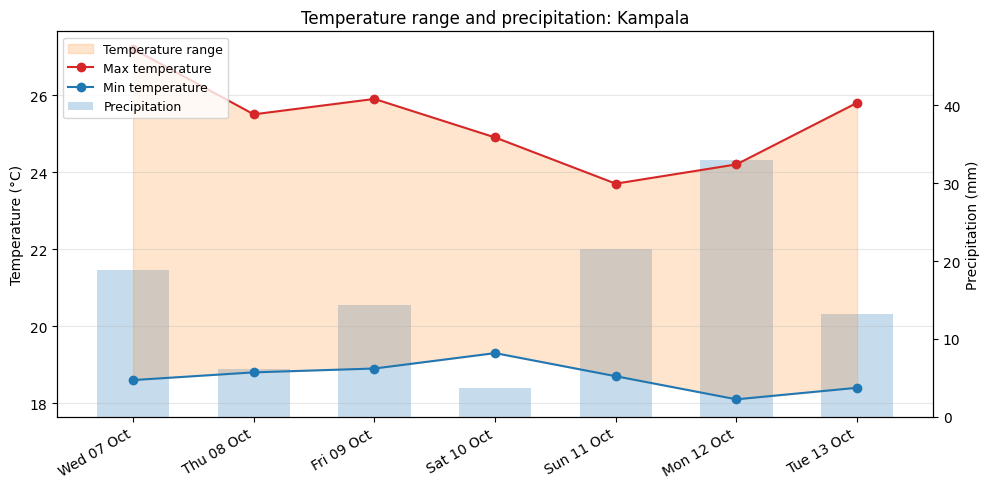

In [83]:
import pandas
from src.weather_report import WeatherReport

try:
    # Allow location input
    location = input("Please provide a location: ")
    place = geocode(location)
    timezone = place.get("timezone", "auto")
    forecast = get_forecast(place["latitude"], place["longitude"], 7, timezone)
    dataframe = forecast_to_dataframe(forecast)
 
    report = WeatherReport(dataframe, place["name"])
    report.show()
except Exception as e:
    print(e)